In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Filter for specific country and drop na values for skills

In [188]:
df_ind = df[df['job_country'] == 'India'].copy()
df_ind = df_ind.dropna(subset=['job_skills'])

### Explode all the skills list and then group by skills and job titles

In [189]:
df_ind_skill = df_ind.explode('job_skills')
df_ind_skill = df_ind_skill.groupby(['job_skills', 'job_title_short']).agg('size')
df_ind_skill = df_ind_skill.reset_index(name='skill_count')
df_ind_skill.sort_values(by='skill_count', ascending=False, inplace=True)
df_ind_skill

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
34,angular.js,Data Scientist,1
49,arch,Business Analyst,1
787,mlpack,Data Engineer,1
1679,yarn,Senior Data Scientist,1


### Job count list

In [154]:
df_ind_jobs_count = df_ind['job_title_short'].value_counts().reset_index(name='job_count')
df_ind_jobs_count

,job_title_short,job_count
0,Data Engineer,17966
1,Data Scientist,11504
2,Data Analyst,4932
3,Senior Data Engineer,4182
4,Senior Data Scientist,2221
5,Software Engineer,1660
6,Business Analyst,1449
7,Senior Data Analyst,943
8,Machine Learning Engineer,629
9,Cloud Engineer,296


### Merge the Skill count with Job count and make new column skill count percent
skill count percent = (skill count/job count) *100

In [155]:
df_ind_skill_perc = pd.merge(df_ind_skill, df_ind_jobs_count, how='left', on='job_title_short')
df_ind_skill_perc['skill_count_perc'] = 100* df_ind_skill_perc['skill_count']/df_ind_skill_perc['job_count']
df_ind_skill_perc

,job_skills,job_title_short,skill_count,job_count,skill_count_perc
0,sql,Data Engineer,12993,17966,72.319938
1,python,Data Engineer,11568,17966,64.388289
2,python,Data Scientist,9248,11504,80.389430
3,spark,Data Engineer,7157,17966,39.836358
4,aws,Data Engineer,6993,17966,38.923522
...,...,...,...,...,...
1684,angular.js,Data Scientist,1,11504,0.008693
1685,arch,Business Analyst,1,1449,0.069013
1686,mlpack,Data Engineer,1,17966,0.005566
1687,yarn,Senior Data Scientist,1,2221,0.045025


### Create a list of specific job titles

In [200]:
job_titles = df_ind['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

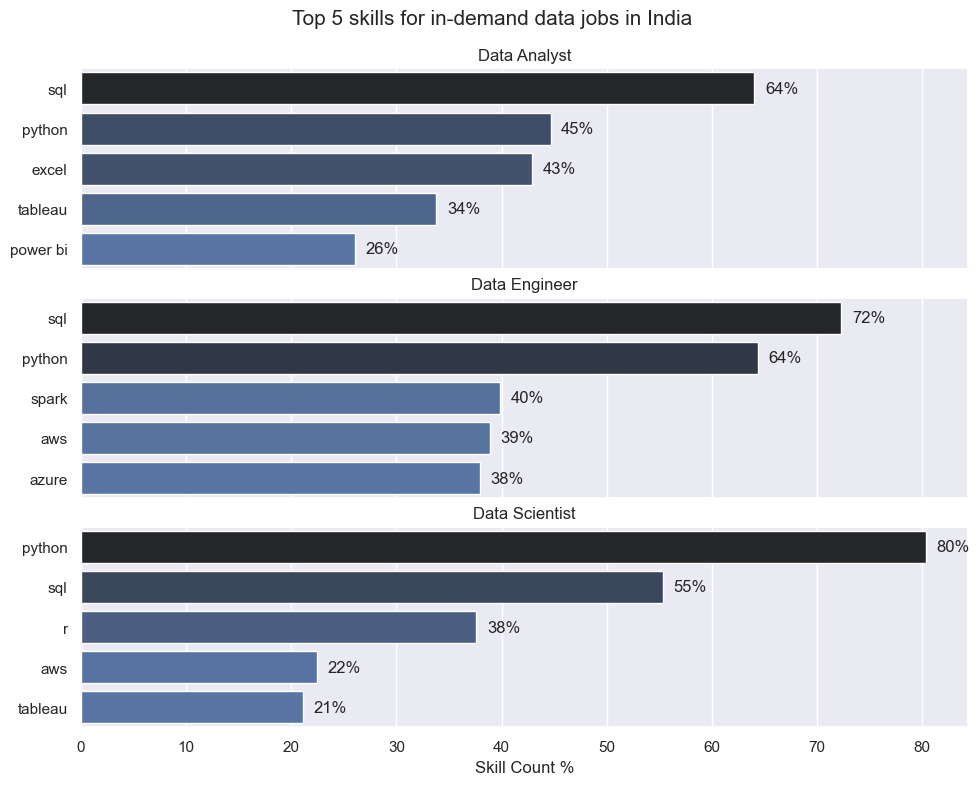

In [198]:
# 2. Setup the plot
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 8), sharex=True)
sns.set_theme(style='darkgrid')

# 3. Loop using a distinct variable name (job_title)
for i, job_title in enumerate(job_titles):
    # Filter for the specific job
    df_plot = df_ind_skill_perc[df_ind_skill_perc['job_title_short'] == job_title].head(5)
    
    # Plotting
    sns.barplot(data=df_plot, x='skill_count_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    
    # Formatting
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('Skill Count %') # Clear individual x-labels for sharex
    ax[i].legend().set_visible(False)

    # Data labels
    for n, v in enumerate(df_plot['skill_count_perc']):
        ax[i].text(v+1, n, f'{v:.0f}%', va='center')

fig.suptitle('Top 5 skills for in-demand data jobs in India', fontsize=15)
plt.tight_layout(h_pad=0.5)
plt.show()